Validation and Learning Curves

In [1]:
import warnings
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
#sharper plots
%config InlineBackend.figure_format = 'retina'

from sklearn.linear_model import (LogisticRegression, LogisticRegressionCV,
                                  SGDClassifier)
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore")

In [2]:
#what if the quality of the model is dissatisfying?

data = pd.read_csv("https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/" + "telecom_churn.csv").drop("State", axis=1)
data["International plan"] = data["International plan"].map({"Yes": 1, "No": 0})
data["Voice mail plan"] = data["Voice mail plan"].map({"Yes": 1, "No": 0})

y = data["Churn"].astype("int").values
X = data.drop("Churn", axis=1).values

In [3]:
#We will train an SVM with stochastic gradient descent

alphas = np.logspace(-4, 0, 20)
sgd_model = SGDClassifier(loss="hinge", n_jobs=-1, random_state=17)
logit_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2)),
        ("sgd_model", sgd_model),
    ]
)
val_train, val_test = validation_curve(
    estimator=logit_pipe, X=X, y=y, param_name="sgd_model__alpha", param_range=alphas, cv=5, scoring="roc_auc"
)

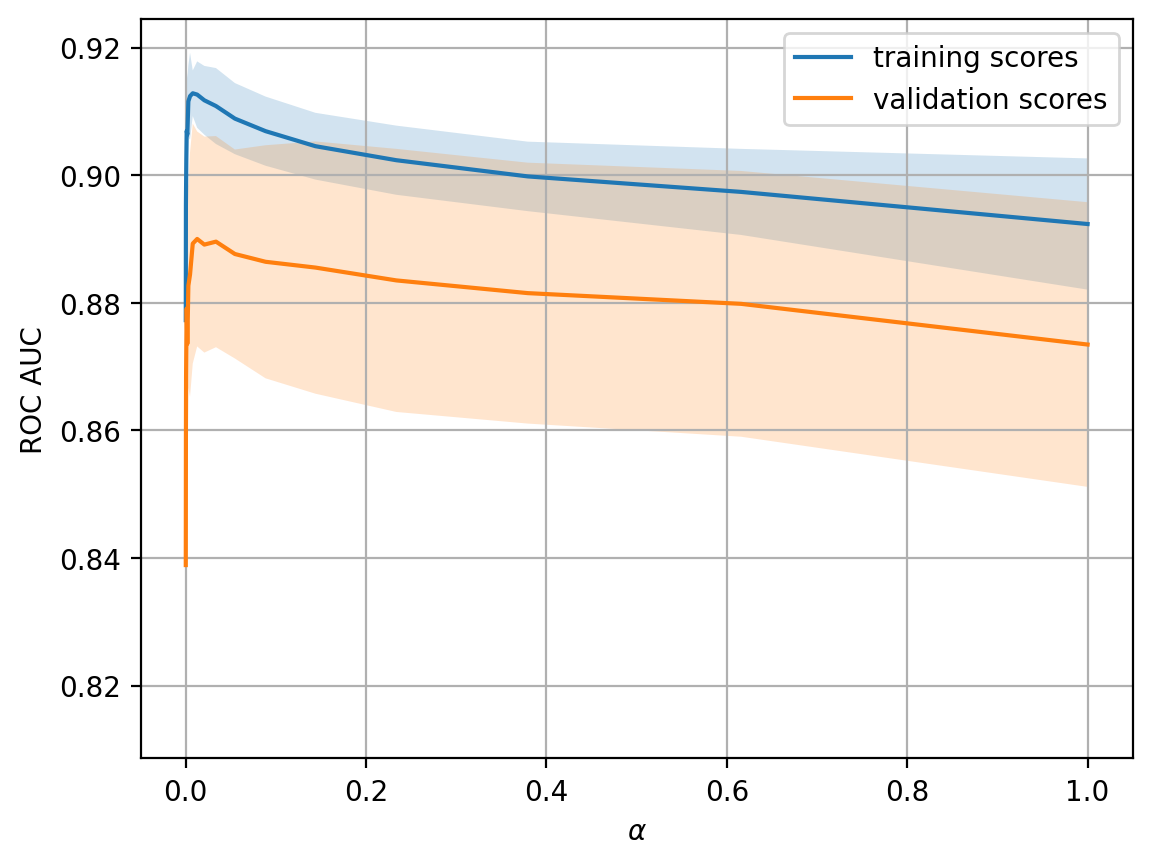

In [4]:
#1st step, construct validation curves showing how the quality on training and test sets varies with the regularization parameter

def plot_with_err(x, data, **kwargs):
    mu, std = data.mean(1), data.std(1)
    lines = plt.plot(x, mu, "-", **kwargs)
    plt.fill_between(
        x,
        mu - std,
        mu + std,
        edgecolor="none",
        facecolor=lines[0].get_color(),
        alpha=0.2,
    )


plot_with_err(alphas, val_train, label="training scores")
plot_with_err(alphas, val_test, label="validation scores")
plt.xlabel(r"$\alpha$")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid(True);

In [5]:
#for simple models, training and validation erros are close and large. This suggests the model is udnerfitted (not enough parameters)
#For highly sophisticated models, training and validation errors differ significantly
#This can be explained by overfitting. When there are too many parameters or regularization is not strict enough, the algorithm can be “distracted” by the noise in the data and lose track of the overall trend.

How much data is needed?

In [7]:
#the more data the better usually, but how do we understand whether new data will be helpful in any given situation?
#Since the new data can be unavailable, it is reasonable to vary the size of the training set and see how the quality of the solution depends on the amount of training data
#This is how we get learning curves.
#the idea is to display the error as a function of the number of examples used in training

def plot_learning_curve(degree=2, alpha=0.01):
    train_sizes = np.linspace(0.05, 1, 20)
    logit_pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=degree)),
            (
                "sgd_model",
                SGDClassifier(n_jobs=-1, random_state=17, alpha=alpha, max_iter=5),
            ),
        ]
    )
    N_train, val_train, val_test = learning_curve(
        logit_pipe, X, y, train_sizes=train_sizes, cv=5, scoring="roc_auc"
    )
    plot_with_err(N_train, val_train, label="training scores")
    plot_with_err(N_train, val_test, label="validation scores")
    plt.xlabel("Training Set Size")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid(True);

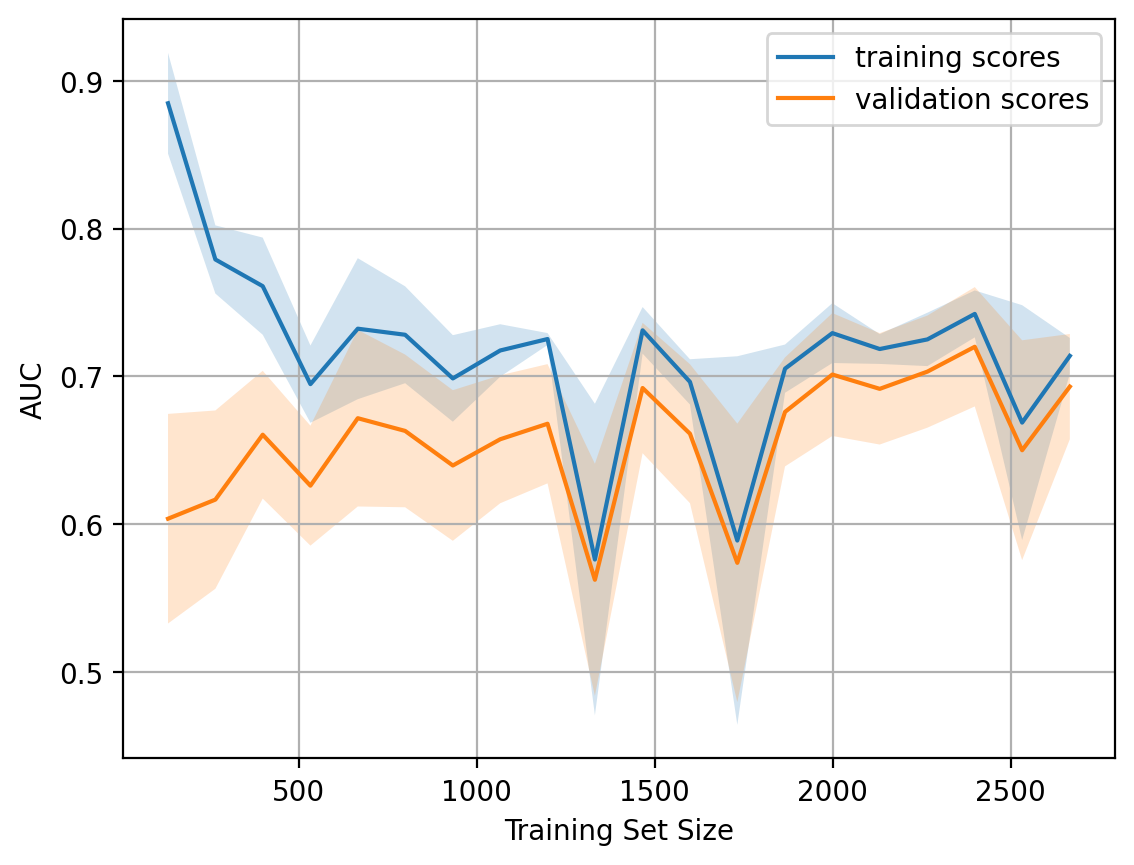

In [8]:
#Let’s see what we get for the linear model. We will set the regularization coefficient to be quite large.

plot_learning_curve(degree=2, alpha=10)

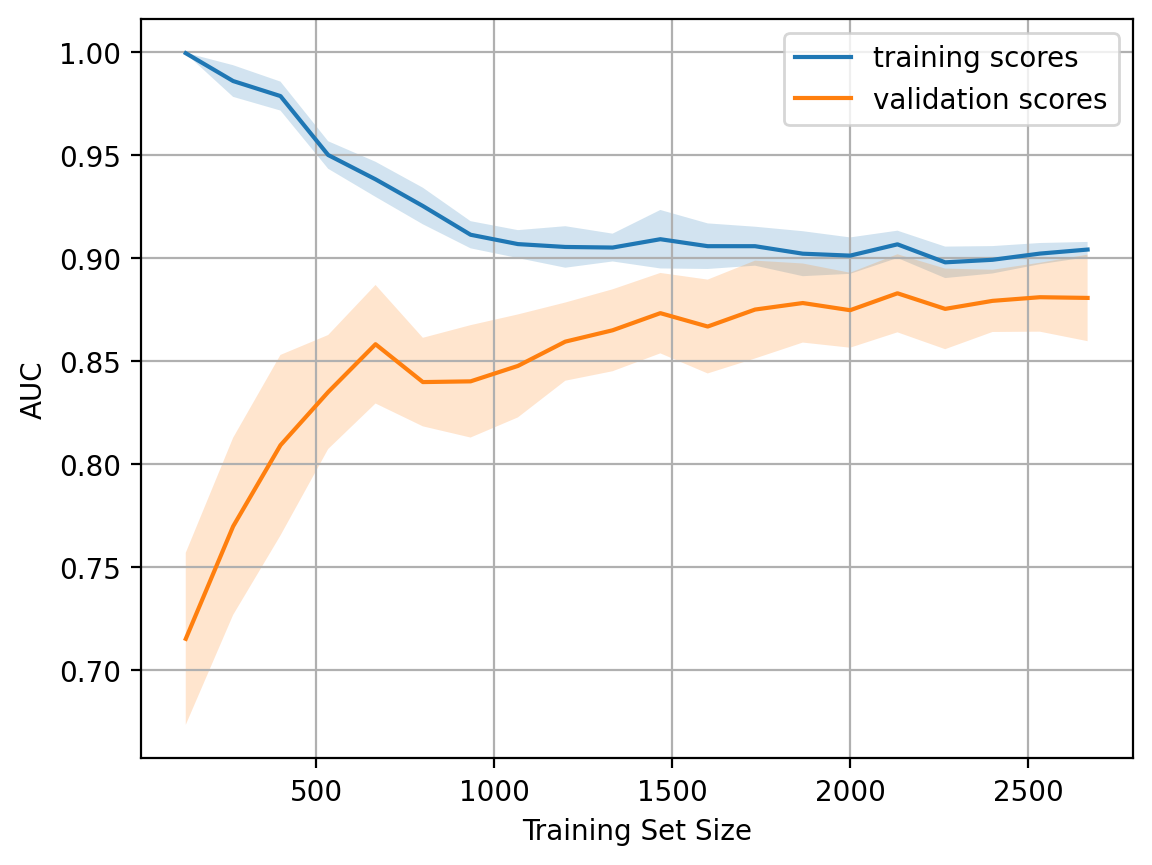

In [9]:
#what happens if we reduce the coefficient to 0.05
#we see a good trend, curves naturally converge
#moving further to the right (add more data to model) we can improve the quality on the validation set even more

plot_learning_curve(degree=2, alpha=0.05)

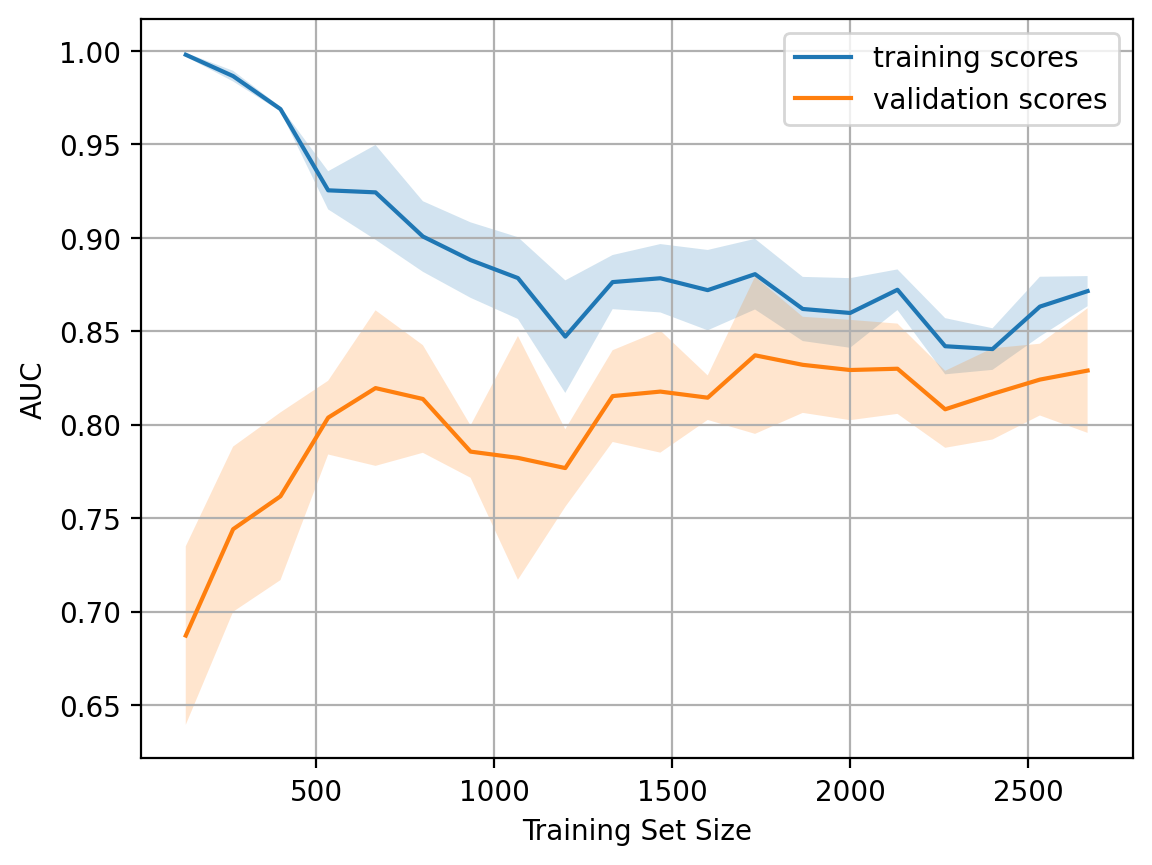

In [10]:
#making the model more complex by setting alpha = 10^-4
#overfitting is seen

plot_learning_curve(degree=2, alpha=1e-4)

Conclusions:

In [11]:
#Error on the training set says nothing about the quality of the model by itself
#Cross-validation error shows how well the model fits the data while retaining the ability to generalize to new data
#if the two curves are close to each other and both errors are large, it is a sign of underfitting
#if the two curves are far from each other, it is a sign of overfitting
#if the curves converge, adding new data won’t help, and it is necessary to change the complexity of the model
#if the curves have not converged, adding new data can improve the result